In [1]:
import lecilab_behavior_analysis.utils as utils
import lecilab_behavior_analysis.df_transforms as dft
import lecilab_behavior_analysis.plots as plots
import lecilab_behavior_analysis.figure_maker as figure_maker
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glmhmmt.model import SoftmaxGLMHMM
from pathlib import Path

%load_ext autoreload
%autoreload 2

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [2]:
project = "COT_cannula_data"
animals = ['NUO001']#, 'NUO002', 'NUO003', 'NUO004', 'NUO005', 'NUO006', 'NUO007', 'NUO008', 'NUO009', 'NUO010', 'NUO011', 'NUO012']
df_list = []
for mouse in animals:
    local_path = Path(utils.get_outpath()) / Path(project) / Path("sessions") / Path(mouse)
    df_animal = pd.read_csv(local_path / Path(f'{mouse}.csv'), sep=";")
    df_list.append(df_animal)
    print(f"Loaded data for {mouse}.")
# concatenate the dataframes
df_raw = pd.concat(df_list, ignore_index=True)
# clear_output(wait=True)
# time.sleep(.5)
print("Data read successfully.")

/tmp/ipykernel_613223/2464295047.py:6: DtypeWarning: Columns (0: STATE_auto_reward_state_left_END, 1: STATE_auto_reward_state_left_START, 2: STATE_reward_state_left_END, 3: STATE_reward_state_left_START, 4: STATE_reward_state_right_END, 5: STATE_reward_state_right_START) have mixed types. Specify dtype option on import or set low_memory=False.
  df_animal = pd.read_csv(local_path / Path(f'{mouse}.csv'), sep=";")


Loaded data for NUO001.
Data read successfully.


In [3]:
df = dft.analyze_df(df_raw)
print("Dataframe analyzed.")

Dataframe analyzed.


In [4]:
# select the date from 2025-10-10, where it did a few performance oscillations
df_sel = df[df['year_month_day'] == '2025-10-10'].copy()

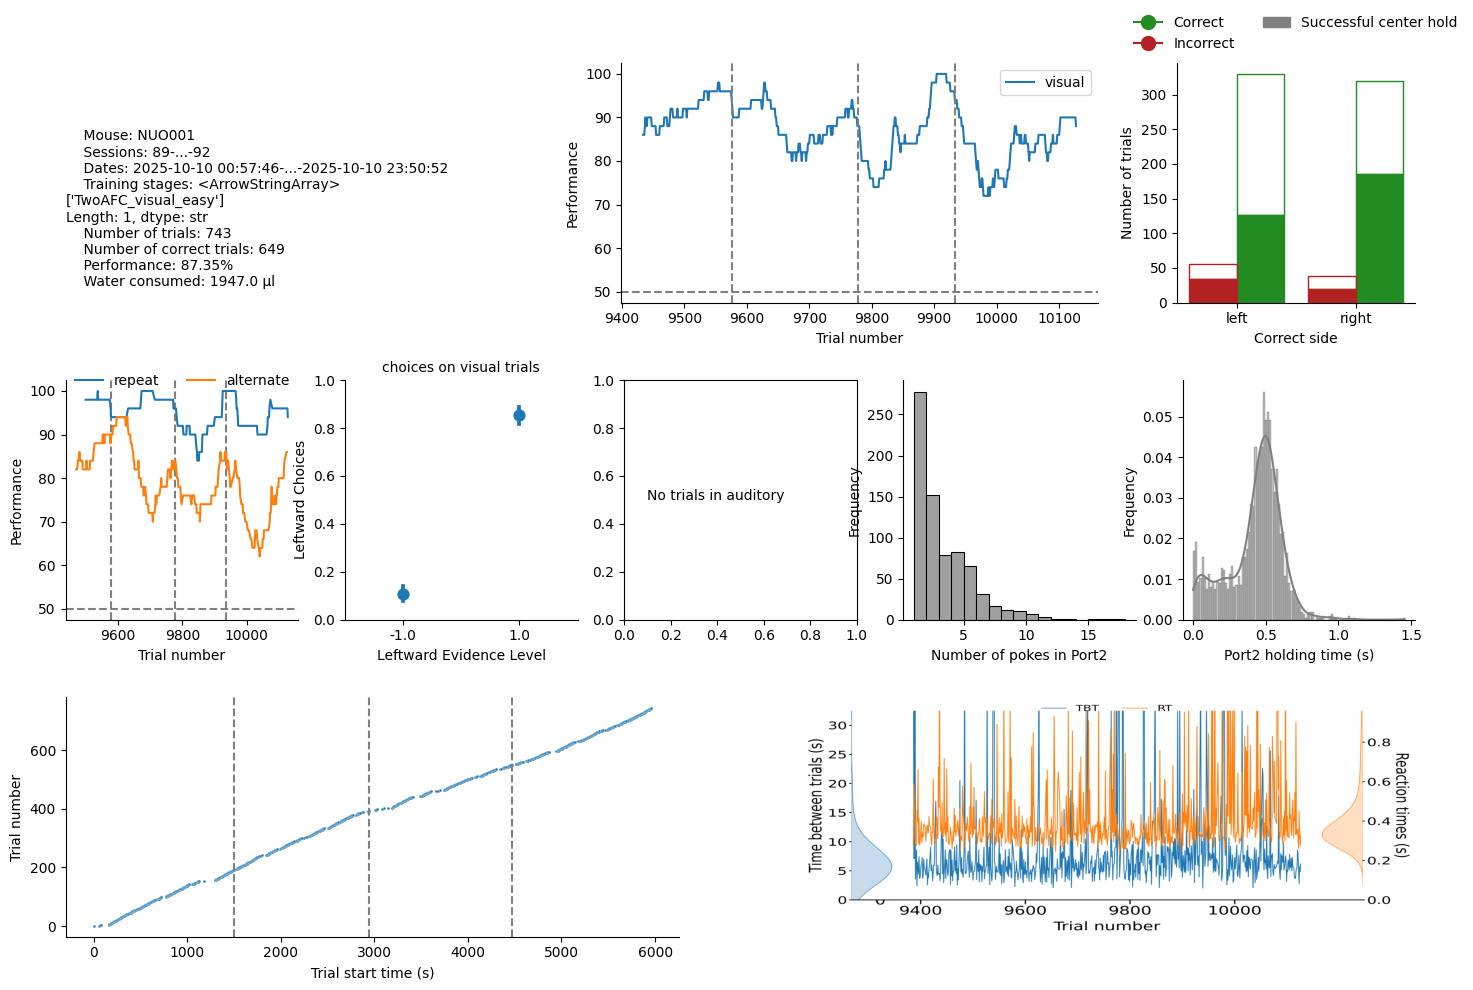

In [5]:
fig = figure_maker.session_summary_figure(df_sel)

In [6]:
import jax.numpy as jnp
import jax.random as jr

In [9]:
df_sel['repeat_or_alternate'] = dft.get_repeat_or_alternate_series(df_sel['first_choice'])

In [47]:
# prepare the data for GLM-HMM fitting to get the probality of going right on each trial
y = df_sel['first_choice'].map({'left': -1, 'right': 1}).values
stimulus_evidence = df_sel['correct_side'].map({'left': -1, 'right': 1}).values
# repeat_or_alternate = df_sel['repeat_or_alternate'].map({'repeat': 1, 'alternate': -1}).values
# get the previous choice using y shifted by 1
previous_choice = np.roll(y, 1)
previous_rewarded = df_sel.correct.map({True: 1, False: 0}).shift(1).values
pRr = (previous_choice == 1) * previous_rewarded
pRu = (previous_choice == 1) * (1 - previous_rewarded)
pLr = (previous_choice == -1) * previous_rewarded
pLu = (previous_choice == -1) * (1 - previous_rewarded)
bias = np.ones_like(y)

inputs = np.column_stack([stimulus_evidence, previous_choice, bias])#, pRr, pRu, pLr, pLu])
inputs_colnames = ['stimulus_evidence', 'previous_choice', 'bias']#, 'pRr', 'pRu', 'pLr', 'pLu']

# delete the first row of inputs and y, since they have NaN values due to the shift
inputs = inputs[1:]
y = y[1:]

# convert to jax arrays
inputs = jnp.array(inputs)
y = jnp.array(y)

In [77]:
num_states = 2
num_classes = 2
emission_input_dim = 3
transition_input_dim = 0

model = SoftmaxGLMHMM(
    num_states=num_states,
    num_classes=num_classes,
    emission_input_dim=emission_input_dim,
    transition_input_dim=transition_input_dim,
    emission_feature_names=inputs_colnames,
    # transition_matrix_stickiness=10
)

In [78]:
params, props = model.initialize()

In [79]:
# fit each session separately
session_ids = df_sel['session'].values[1:] # get the session ids, also delete the first one to match the inputs and y

In [80]:
fitted_params, log_probs = model.fit_em_multisession(
    params,
    props,
    y,
    inputs,
    session_ids=session_ids,
    num_iters=500,
    verbose=True,
)

EM:   0%|          | 0/500 [00:00<?, ?it/s]

In [81]:
fitted_params

ParamsSoftmaxGLMHMM(initial=ParamsStandardHMMInitialState(probs=Array([0.49999705, 0.500003  ], dtype=float32)), transitions=ParamsStandardHMMTransitions(transition_matrix=Array([[0.22202168, 0.77797836],
       [0.87286866, 0.1271314 ]], dtype=float32)), emissions=ParamsSoftmaxGLMHMMEmissions(weights=Array([[[ -0.9316958 ,  -0.42278606, -10.974652  ]],

       [[ -0.9306399 ,  -0.42215872, -10.868362  ]]], dtype=float32)))

In [82]:
pred = model.predict_choice_probs(fitted_params, y, inputs)
# transition = model.get_transition_matrices(fitted_params)
print("log_probs:", log_probs)
print("pred shape:", pred.shape)

log_probs: [-4.53641907e+02 -1.69313446e+02 -8.23787308e+01 -4.60765762e+01
 -3.16548977e+01 -2.38022461e+01 -1.87069530e+01 -1.51239557e+01
 -1.24869709e+01 -1.04856491e+01 -8.93066597e+00 -7.69873571e+00
 -6.70629501e+00 -5.89498520e+00 -5.22297049e+00 -4.65992117e+00
 -4.18330002e+00 -3.77610731e+00 -3.42522669e+00 -3.12075996e+00
 -2.85473442e+00 -2.62081933e+00 -2.41406178e+00 -2.23032570e+00
 -2.06632543e+00 -1.91930056e+00 -1.78697741e+00 -1.66748619e+00
 -1.55915511e+00 -1.46074104e+00 -1.37095749e+00 -1.28891540e+00
 -1.21377778e+00 -1.14468443e+00 -1.08109391e+00 -1.02244580e+00
 -9.68261540e-01 -9.18097675e-01 -8.71564448e-01 -8.28304350e-01
 -7.88091660e-01 -7.50663161e-01 -7.15671957e-01 -6.83068871e-01
 -6.52528107e-01 -6.23934984e-01 -5.97112417e-01 -5.72025001e-01
 -5.48436761e-01 -5.26236951e-01 -5.05341649e-01 -4.85678583e-01
 -4.67136592e-01 -4.49670553e-01 -4.33170974e-01 -4.17568088e-01
 -4.02821451e-01 -3.88900697e-01 -3.75689089e-01 -3.63223314e-01
 -3.51381898e-

In [83]:
states = model.predict_state_probs(fitted_params, y, inputs)
# get only one column
state_one = states[:,0]
state_one.shape

(742,)

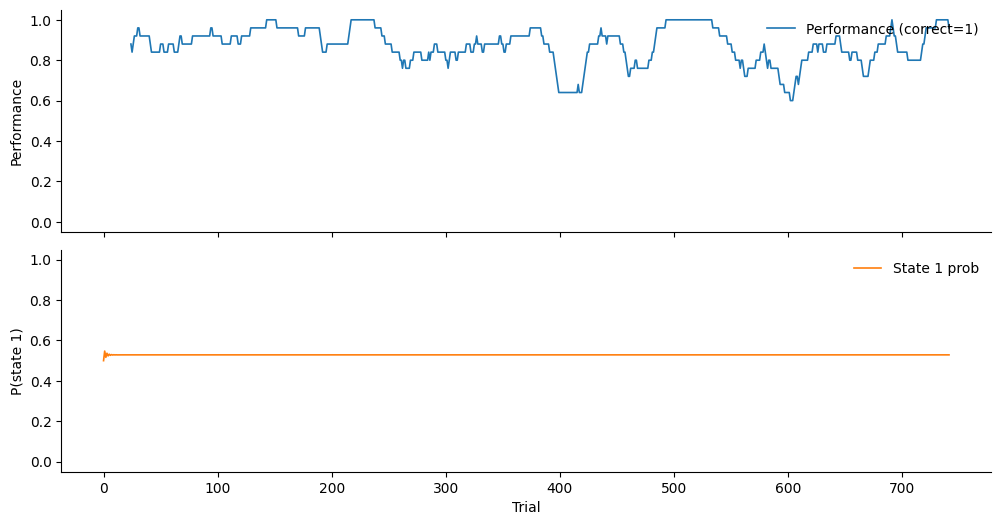

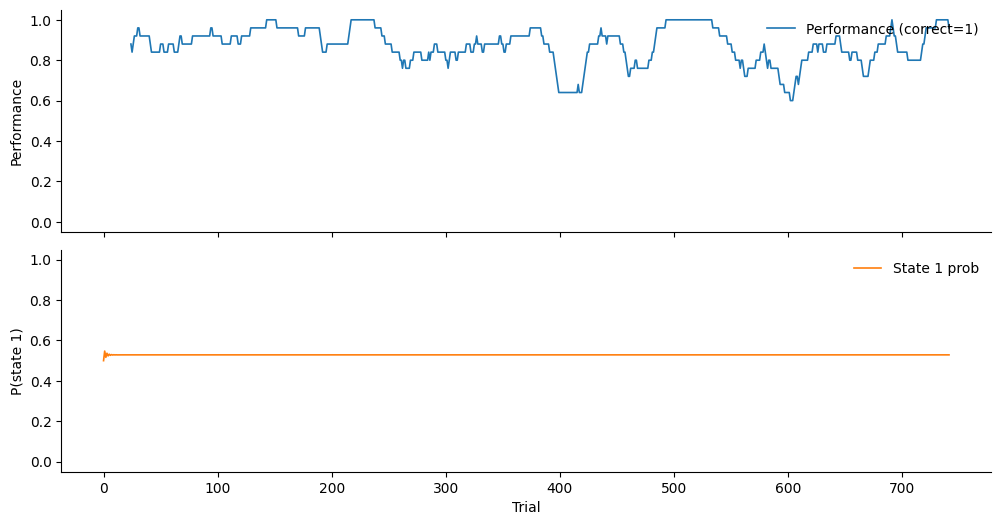

In [88]:
# Performance (top) and state-1 probability (bottom) with shared x-axis
performance_trace = pd.Series(df_sel["correct"].astype(float).values[1:])
# create a rolling average
rolled_performance = performance_trace.rolling(window=25).mean()

state_one_np = np.asarray(state_one)

fig, (ax_perf, ax_state) = plt.subplots(
    2, 1, figsize=(12, 6), sharex=True, gridspec_kw={"hspace": 0.08}
)

ax_perf.plot(rolled_performance, color="tab:blue", linewidth=1.2, label="Performance (correct=1)")
ax_perf.set_ylabel("Performance")
ax_perf.set_ylim(-0.05, 1.05)
ax_perf.legend(loc="upper right", frameon=False)

ax_state.plot(state_one_np, color="tab:orange", linewidth=1.2, label="State 1 prob")
ax_state.set_ylabel("P(state 1)")
ax_state.set_xlabel("Trial")
ax_state.set_ylim(-0.05, 1.05)
ax_state.legend(loc="upper right", frameon=False)

sns.despine()
fig

In [67]:
state_one

Array([0.49999827, 0.54750574, 0.5165491 , 0.53672117, 0.5235768 ,
       0.532142  , 0.52656084, 0.5301975 , 0.5278276 , 0.52937204,
       0.52836543, 0.52902156, 0.52859384, 0.52887267, 0.528691  ,
       0.5288095 , 0.52873206, 0.5287826 , 0.5287497 , 0.52877116,
       0.52875715, 0.5287663 , 0.52876043, 0.528764  , 0.5287618 ,
       0.52876335, 0.52876234, 0.52876276, 0.5287627 , 0.52876276,
       0.5287627 , 0.5287625 , 0.52876276, 0.5287622 , 0.528763  ,
       0.5287626 , 0.5287628 , 0.52876264, 0.52876276, 0.52876246,
       0.5287628 , 0.52876264, 0.5287623 , 0.528763  , 0.52876234,
       0.52876294, 0.52876234, 0.528763  , 0.52876264, 0.5287626 ,
       0.5287627 , 0.52876276, 0.52876246, 0.5287628 , 0.5287627 ,
       0.52876276, 0.52876246, 0.5287629 , 0.52876264, 0.52876276,
       0.52876246, 0.52876294, 0.52876264, 0.52876276, 0.5287627 ,
       0.5287626 , 0.5287628 , 0.52876246, 0.5287628 , 0.52876264,
       0.5287623 , 0.52876294, 0.5287626 , 0.5287626 , 0.52876